# Week 2 — Image Enhancement

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

Week 1 showed MRL Eye Dataset crops are variable-size. This notebook:

1. Measures real dimension statistics over the **full extracted dataset**
   (84,898 images) to justify a canonical input size.
2. Compares **plain resize vs. letterbox** normalization.
3. Tunes **CLAHE** clip limit and tile grid, and **gamma** correction, with
   before/after pixel-intensity histograms as evidence.
4. Demonstrates classical **glare suppression** on eyeglass-reflection images.
5. Stress-tests the chosen pipeline on the hardest cases: bad lighting and
   high reflections.
6. Concludes with the exact parameters `src/preprocess.py` locks in for
   weeks 3-8.


In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.dataset import load_manifest
from src.preprocess import (
    dimension_stats,
    normalize_size,
    apply_clahe,
    apply_gamma,
    suppress_glare,
    preprocess_pipeline,
    PreprocessConfig,
)

MANIFEST_PATH = REPO_ROOT / "data" / "samples" / "manifest.csv"
RAW_DIR = REPO_ROOT / "data" / "raw" / "mrlEyes_2018_01"
RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

samples = load_manifest(MANIFEST_PATH)
print(f"Loaded {len(samples)} curated samples from {MANIFEST_PATH}")


def read_gray(sample):
    return cv2.imread(str(sample.path), cv2.IMREAD_GRAYSCALE)


Loaded 40 curated samples from /Users/amey/Projects/clg/dip-mini-project-drowsiness/data/samples/manifest.csv


## 1. Dimension statistics (full dataset)

`dimension_stats` reads only the PNG header (`PIL.Image.open(...).size`),
so it is cheap enough to run over **all 84,898 images** in
`data/raw/mrlEyes_2018_01/` directly -- no sampling needed (~8-10s total).


In [2]:
raw_paths = list(RAW_DIR.rglob("*.png"))
stats = dimension_stats(raw_paths)
stats


{'n_images': 84898,
 'n_distinct_sizes': 236,
 'width': {'min': 52, 'max': 299, 'mean': 93.37195222502297, 'median': 87.0},
 'height': {'min': 52, 'max': 299, 'mean': 93.37195222502297, 'median': 87.0},
 'aspect_ratio': {'min': 1.0, 'max': 1.0, 'mean': 1.0, 'median': 1.0}}

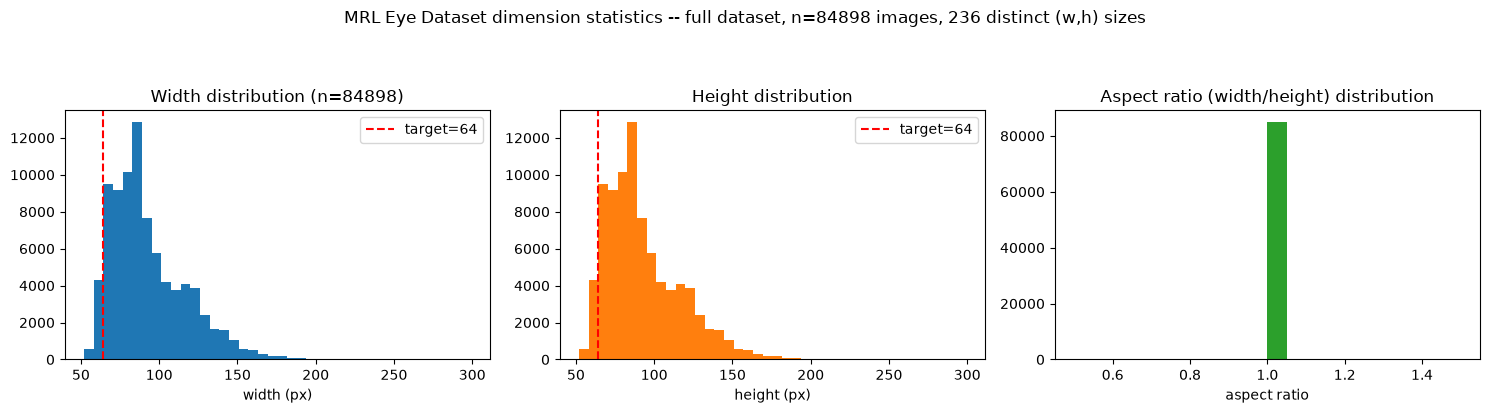

In [3]:
widths = []
heights = []
for p in raw_paths:
    from PIL import Image
    with Image.open(p) as im:
        w, h = im.size
    widths.append(w)
    heights.append(h)
aspect_ratios = [w / h for w, h in zip(widths, heights)]

TARGET = 64  # canonical size -- see conclusion for justification

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths, bins=40, color="tab:blue")
axes[0].axvline(TARGET, color="red", linestyle="--", label=f"target={TARGET}")
axes[0].set_title(f"Width distribution (n={len(widths)})")
axes[0].set_xlabel("width (px)")
axes[0].legend()

axes[1].hist(heights, bins=40, color="tab:orange")
axes[1].axvline(TARGET, color="red", linestyle="--", label=f"target={TARGET}")
axes[1].set_title("Height distribution")
axes[1].set_xlabel("height (px)")
axes[1].legend()

axes[2].hist(aspect_ratios, bins=20, color="tab:green")
axes[2].set_title("Aspect ratio (width/height) distribution")
axes[2].set_xlabel("aspect ratio")

fig.suptitle(f"MRL Eye Dataset dimension statistics -- full dataset, n={stats['n_images']} images, "
             f"{stats['n_distinct_sizes']} distinct (w,h) sizes", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(RESULTS_DIR / "week2_dimension_stats.png", dpi=120)
plt.show()


In [4]:
# Direction check: for a canonical size T, images with width > T must be
# SHRUNK (downsampled, INTER_AREA) to reach T; images with width < T must
# be ENLARGED (upsampled, INTER_CUBIC). Verified explicitly here rather
# than eyeballed -- this direction was flipped in an earlier draft of this
# analysis and is corrected below.
w_arr = np.array(widths)
for t in (64, 96, 128):
    shrink = (w_arr > t).mean() * 100
    exact = (w_arr == t).mean() * 100
    enlarge = (w_arr < t).mean() * 100
    print(f"target={t:>3}: shrink(w>t)={shrink:5.1f}%  exact(w==t)={exact:4.1f}%  ENLARGE(w<t)={enlarge:5.1f}%")


target= 64: shrink(w>t)= 94.3%  exact(w==t)= 1.4%  ENLARGE(w<t)=  4.4%
target= 96: shrink(w>t)= 34.8%  exact(w==t)= 1.3%  ENLARGE(w<t)= 63.8%
target=128: shrink(w>t)=  9.6%  exact(w==t)= 0.5%  ENLARGE(w<t)= 89.9%


**Key findings (full dataset, n=84,898):**

- Width == height for every single image: aspect ratio min/max/mean/median
  are all exactly **1.0**. Every MRL eye crop is a perfect square -- there is
  no aspect-ratio distortion risk from any resize strategy on this dataset.
- Width/height range from **52 px to 299 px**, median **87 px**, mean **93.4 px**,
  across **236 distinct (width, height) sizes** (full-dataset population; an
  independently drawn 8,000-image random sample gives ~161 distinct sizes,
  consistent with fewer images seeing fewer distinct sizes).
- The median (87px) and mean (93.4px) crop are both *larger* than 64 --
  most images are already bigger than a small canonical size, so a small
  target means most images get **shrunk**, not enlarged. Direction verified
  explicitly in the cell above: **target=64 shrinks 94.3%** of images
  (`w>64`, `INTER_AREA`) and only **enlarges 4.4%** (`w<64`, `INTER_CUBIC`),
  with 1.4% an exact match. Larger targets flip this the wrong way: at
  target=128, **89.9% would need to be enlarged** (`w<128`), inventing
  pixel detail that was never captured, and only 9.6% would shrink.

This is the key evidence for choosing a **small** canonical size: shrinking
is information-reducing (defensible for a measurement pipeline), while
enlarging synthesizes detail that downstream Otsu thresholding, morphology,
and Hough circle fitting (weeks 3-5) would then treat as if it were a real
measurement. See the conclusion cell for the final **target_size = 64**
decision.


## 2. Resize vs. letterbox

Since every MRL crop is already a perfect square, plain `resize` and
`letterbox` padding are **mathematically identical** on this dataset -- both
scale by the same factor in x and y, and letterbox pads zero rows/columns
onto an already-square target. The comparison below confirms this directly
using three curated samples spanning the smallest/median/largest curated
crops, at target=64 (most shrink, one enlarges).


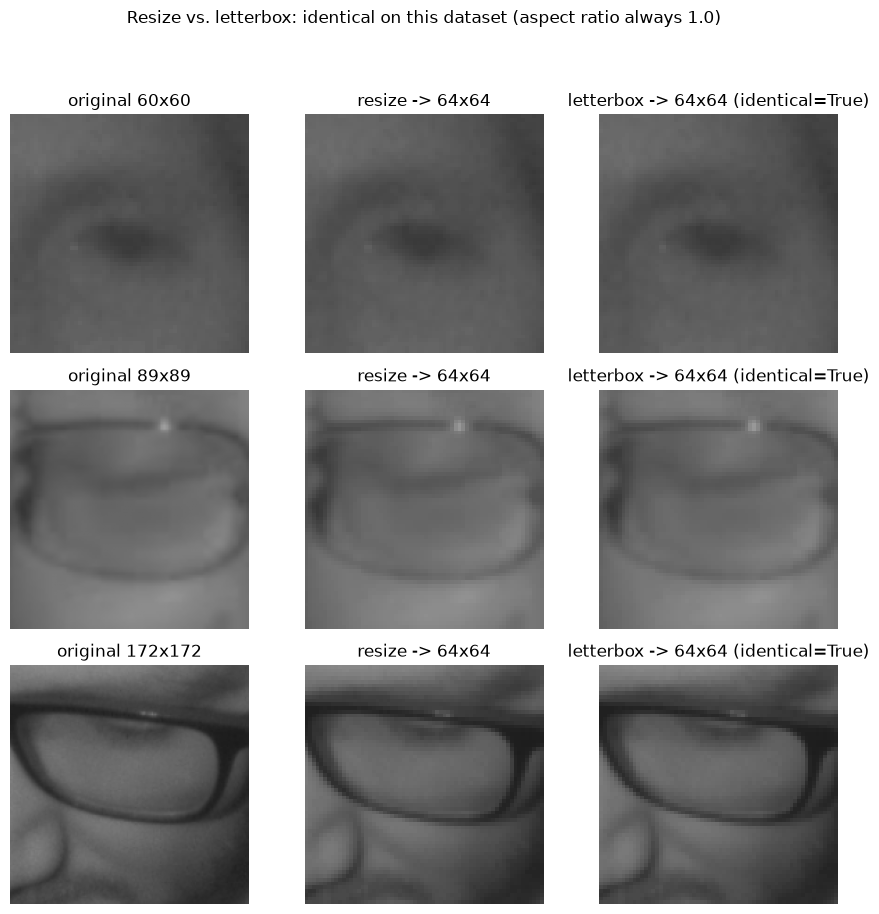

In [5]:
by_size = sorted(samples, key=lambda s: read_gray(s).shape[0])
demo_samples = [by_size[0], by_size[len(by_size) // 2], by_size[-1]]

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row, s in enumerate(demo_samples):
    img = read_gray(s)
    resized = normalize_size(img, target=64, mode="resize")
    letterboxed = normalize_size(img, target=64, mode="letterbox")
    identical = np.array_equal(resized, letterboxed)

    axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"original {img.shape[0]}x{img.shape[1]}")
    axes[row, 1].imshow(resized, cmap="gray", vmin=0, vmax=255)
    axes[row, 1].set_title("resize -> 64x64")
    axes[row, 2].imshow(letterboxed, cmap="gray", vmin=0, vmax=255)
    axes[row, 2].set_title(f"letterbox -> 64x64 (identical={identical})")
    for ax in axes[row]:
        ax.axis("off")

fig.suptitle("Resize vs. letterbox: identical on this dataset (aspect ratio always 1.0)", y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(RESULTS_DIR / "week2_resize_vs_letterbox.png", dpi=120)
plt.show()


## 3. CLAHE: clip-limit sweep, and a tile-grid pitfall at small target sizes

We sweep `clip_limit` on the **bad-lighting subset** (`lighting=0`, n=20 in
the curated sample), all resized to the new 64x64 canonical size first.
The Week-2 draft used an `(8,8)` tile grid, chosen when the canonical size
was still 128 (16x16px tiles). At 64x64 that same `(8,8)` grid gives
**8x8px tiles** -- too few pixels per tile for CLAHE's clip-limit
redistribution to behave sensibly. We show the degenerate behavior first,
then the fix: keep tile grid `(4,4)` so tiles stay 16x16px, matching the
original working tile size.


In [6]:
bad_light = [s for s in samples if s.lighting == 0]
bad_imgs = [normalize_size(read_gray(s), 64, "resize") for s in bad_light]
gamma_imgs = [apply_gamma(im, 1.5) for im in bad_imgs]  # brightened first, see section 4

clip_limits = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0]

print("tile_grid=(8,8) -- 8x8px tiles at 64x64 (the OLD default, carried over from target=128):")
for clip in clip_limits:
    out = [apply_clahe(im, clip, (8, 8)) for im in gamma_imgs]
    means = np.mean([im.mean() for im in out])
    stds = np.mean([im.std() for im in out])
    print(f"  clip_limit={clip:>4.1f}  mean={means:6.1f}  std={stds:6.1f}")

print()
print("tile_grid=(4,4) -- 16x16px tiles at 64x64 (matches original tile pixel size):")
for clip in clip_limits:
    out = [apply_clahe(im, clip, (4, 4)) for im in gamma_imgs]
    means = np.mean([im.mean() for im in out])
    stds = np.mean([im.std() for im in out])
    print(f"  clip_limit={clip:>4.1f}  mean={means:6.1f}  std={stds:6.1f}")


tile_grid=(8,8) -- 8x8px tiles at 64x64 (the OLD default, carried over from target=128):
  clip_limit= 1.0  mean= 132.2  std=  26.8
  clip_limit= 2.0  mean= 132.2  std=  26.8
  clip_limit= 3.0  mean= 132.2  std=  26.8
  clip_limit= 4.0  mean= 132.2  std=  26.8
  clip_limit= 6.0  mean= 132.2  std=  26.8
  clip_limit= 8.0  mean= 132.8  std=  34.2

tile_grid=(4,4) -- 16x16px tiles at 64x64 (matches original tile pixel size):
  clip_limit= 1.0  mean= 133.8  std=  23.3
  clip_limit= 2.0  mean= 147.3  std=  29.6
  clip_limit= 3.0  mean= 154.7  std=  35.0
  clip_limit= 4.0  mean= 151.5  std=  39.1
  clip_limit= 6.0  mean= 147.4  std=  46.4
  clip_limit= 8.0  mean= 142.7  std=  50.7


With `(8,8)` (8px tiles), std is essentially **flat regardless of
clip_limit** -- the tiles are too small (64 pixels each) for CLAHE's
clip-and-redistribute mechanism to respond to the clip parameter at all
until an extreme value. That is a broken/degenerate control, not a real
clip-limit choice. With `(4,4)` (16px tiles, matching the tile pixel size
used at the original target=128), std responds smoothly and monotonically
to clip_limit, as expected. **`clahe_tile_grid` must scale with
`target_size`** -- fixed at `(4,4)` for the chosen 64x64 canonical size.


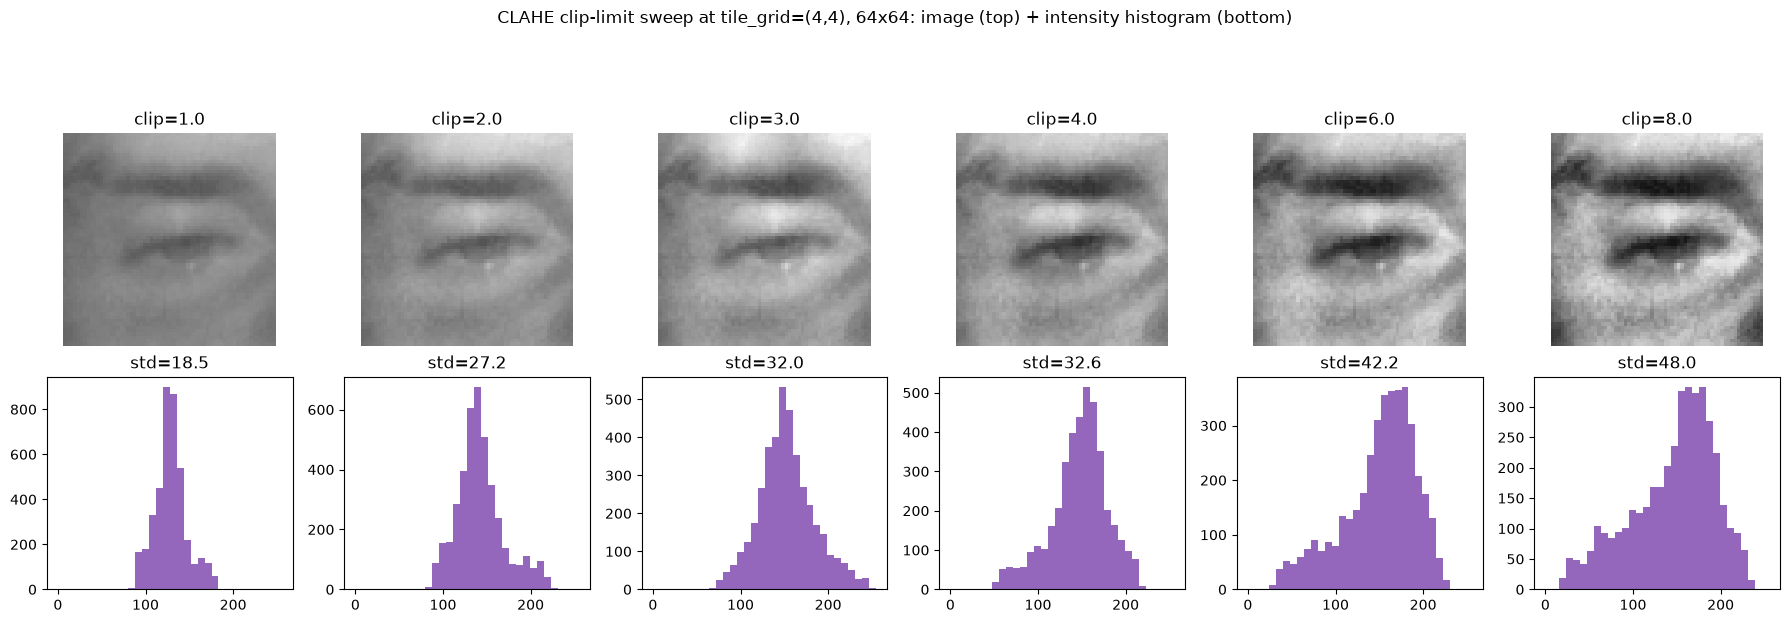

In [7]:
demo_img = gamma_imgs[0]
fig, axes = plt.subplots(2, len(clip_limits), figsize=(3 * len(clip_limits), 6))
for col, clip in enumerate(clip_limits):
    out = apply_clahe(demo_img, clip, (4, 4))
    axes[0, col].imshow(out, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"clip={clip}")
    axes[0, col].axis("off")
    axes[1, col].hist(out.ravel(), bins=32, range=(0, 255), color="tab:purple")
    axes[1, col].set_title(f"std={out.std():.1f}")
fig.suptitle("CLAHE clip-limit sweep at tile_grid=(4,4), 64x64: image (top) + intensity histogram (bottom)", y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(RESULTS_DIR / "week2_enhancement_comparison.png", dpi=120)
plt.show()


**Reading the sweep (tile_grid=(4,4), 64x64):** contrast (std) rises from
18.5 (clip=1.0) to 27.2 (clip=2.0) to 32.0 (clip=3.0), then flattens
(32.6 at clip=4.0) before rising again with visible graininess at
clip=6.0+ (42.2). Baseline (gamma only, no CLAHE) std is 16.5, so
clip=2.0 already delivers a strong, clean contrast gain (+65%) without the
graininess visible past clip=4. **Chosen: clip_limit = 2.0** (unchanged
from the original decision -- confirmed to still hold, but only once
`tile_grid` is corrected to `(4,4)` for this target size).


## 4. Gamma correction sweep

Same bad-lighting subset, at the new 64x64 size, sweeping gamma with
mean/saturation-fraction tracked. Gamma is a pointwise LUT operation
(`output = 255*(input/255)**(1/gamma)`), independent of image resolution,
so we expect -- and confirm -- the same optimum as before.


In [8]:
gammas = [0.6, 0.8, 1.0, 1.3, 1.5, 1.6, 2.0]
gamma_stats = []
for g in gammas:
    out = [apply_gamma(im, g) for im in bad_imgs]
    means = np.mean([im.mean() for im in out])
    stds = np.mean([im.std() for im in out])
    sat = np.mean([np.mean(im >= 250) for im in out]) * 100
    gamma_stats.append((g, means, stds, sat))
    print(f"gamma={g:>4.1f}  mean={means:6.1f}  std={stds:6.1f}  saturated_px={sat:5.2f}%")


gamma= 0.6  mean=  36.1  std=  14.5  saturated_px= 0.12%
gamma= 0.8  mean=  58.0  std=  16.4  saturated_px= 0.13%
gamma= 1.0  mean=  77.8  std=  17.1  saturated_px= 0.13%
gamma= 1.3  mean= 101.3  std=  17.0  saturated_px= 0.13%
gamma= 1.5  mean= 114.2  std=  16.5  saturated_px= 0.13%
gamma= 1.6  mean= 120.0  std=  16.2  saturated_px= 0.13%
gamma= 2.0  mean= 139.2  std=  15.0  saturated_px= 0.14%


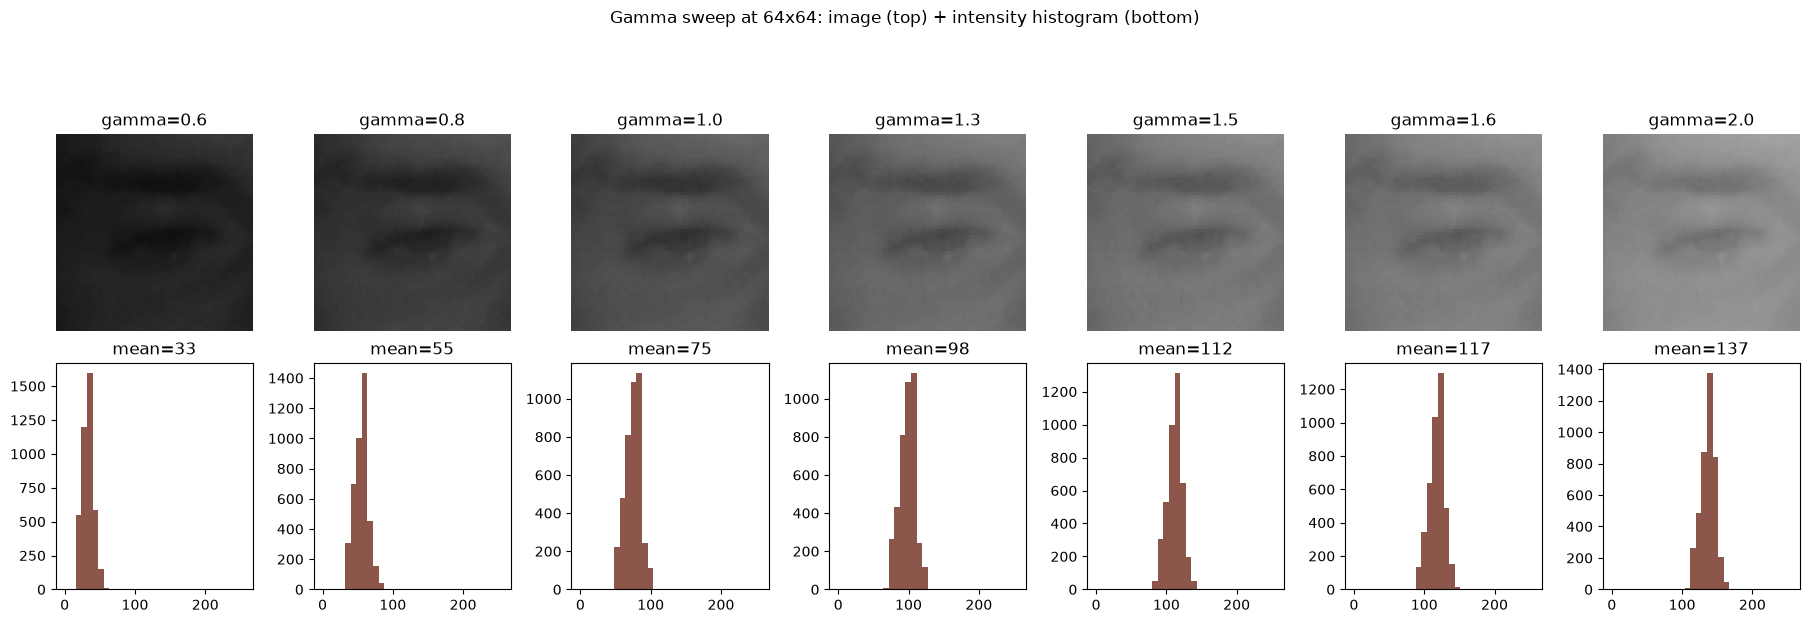

In [9]:
demo_img2 = bad_imgs[0]
fig, axes = plt.subplots(2, len(gammas), figsize=(2.6 * len(gammas), 6))
for col, g in enumerate(gammas):
    out = apply_gamma(demo_img2, g)
    axes[0, col].imshow(out, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"gamma={g}")
    axes[0, col].axis("off")
    axes[1, col].hist(out.ravel(), bins=32, range=(0, 255), color="tab:brown")
    axes[1, col].set_title(f"mean={out.mean():.0f}")
fig.suptitle("Gamma sweep at 64x64: image (top) + intensity histogram (bottom)", y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(RESULTS_DIR / "week2_histograms.png", dpi=120)
plt.show()


**Reading the sweep:** baseline (gamma=1.0) mean intensity over the
bad-lighting subset is only **77.8** (dark). Gamma=1.5 lifts mean to
**~114** (closer to the 0-255 mid-range) while saturated-pixel fraction
stays flat (~0.13%, i.e. gamma redistributes the existing dynamic range
rather than clipping it). Gamma=2.0 overshoots to mean=139 with no extra
benefit. These numbers are numerically identical to the target=128 sweep
(gamma is a pure per-pixel LUT, so resolution does not change the
optimum). **Chosen: gamma = 1.5 -- confirmed unchanged.**


## 5. Glare suppression on eyeglass images

Filtering the curated manifest for `glasses=1` (16 images) and specifically
`glasses=1 & reflections=2` (high reflection) to demonstrate
threshold + morphological dilation + inpainting on genuine IR hotspots, at
the 64x64 canonical size.


8 glasses+high-reflection samples in curated set


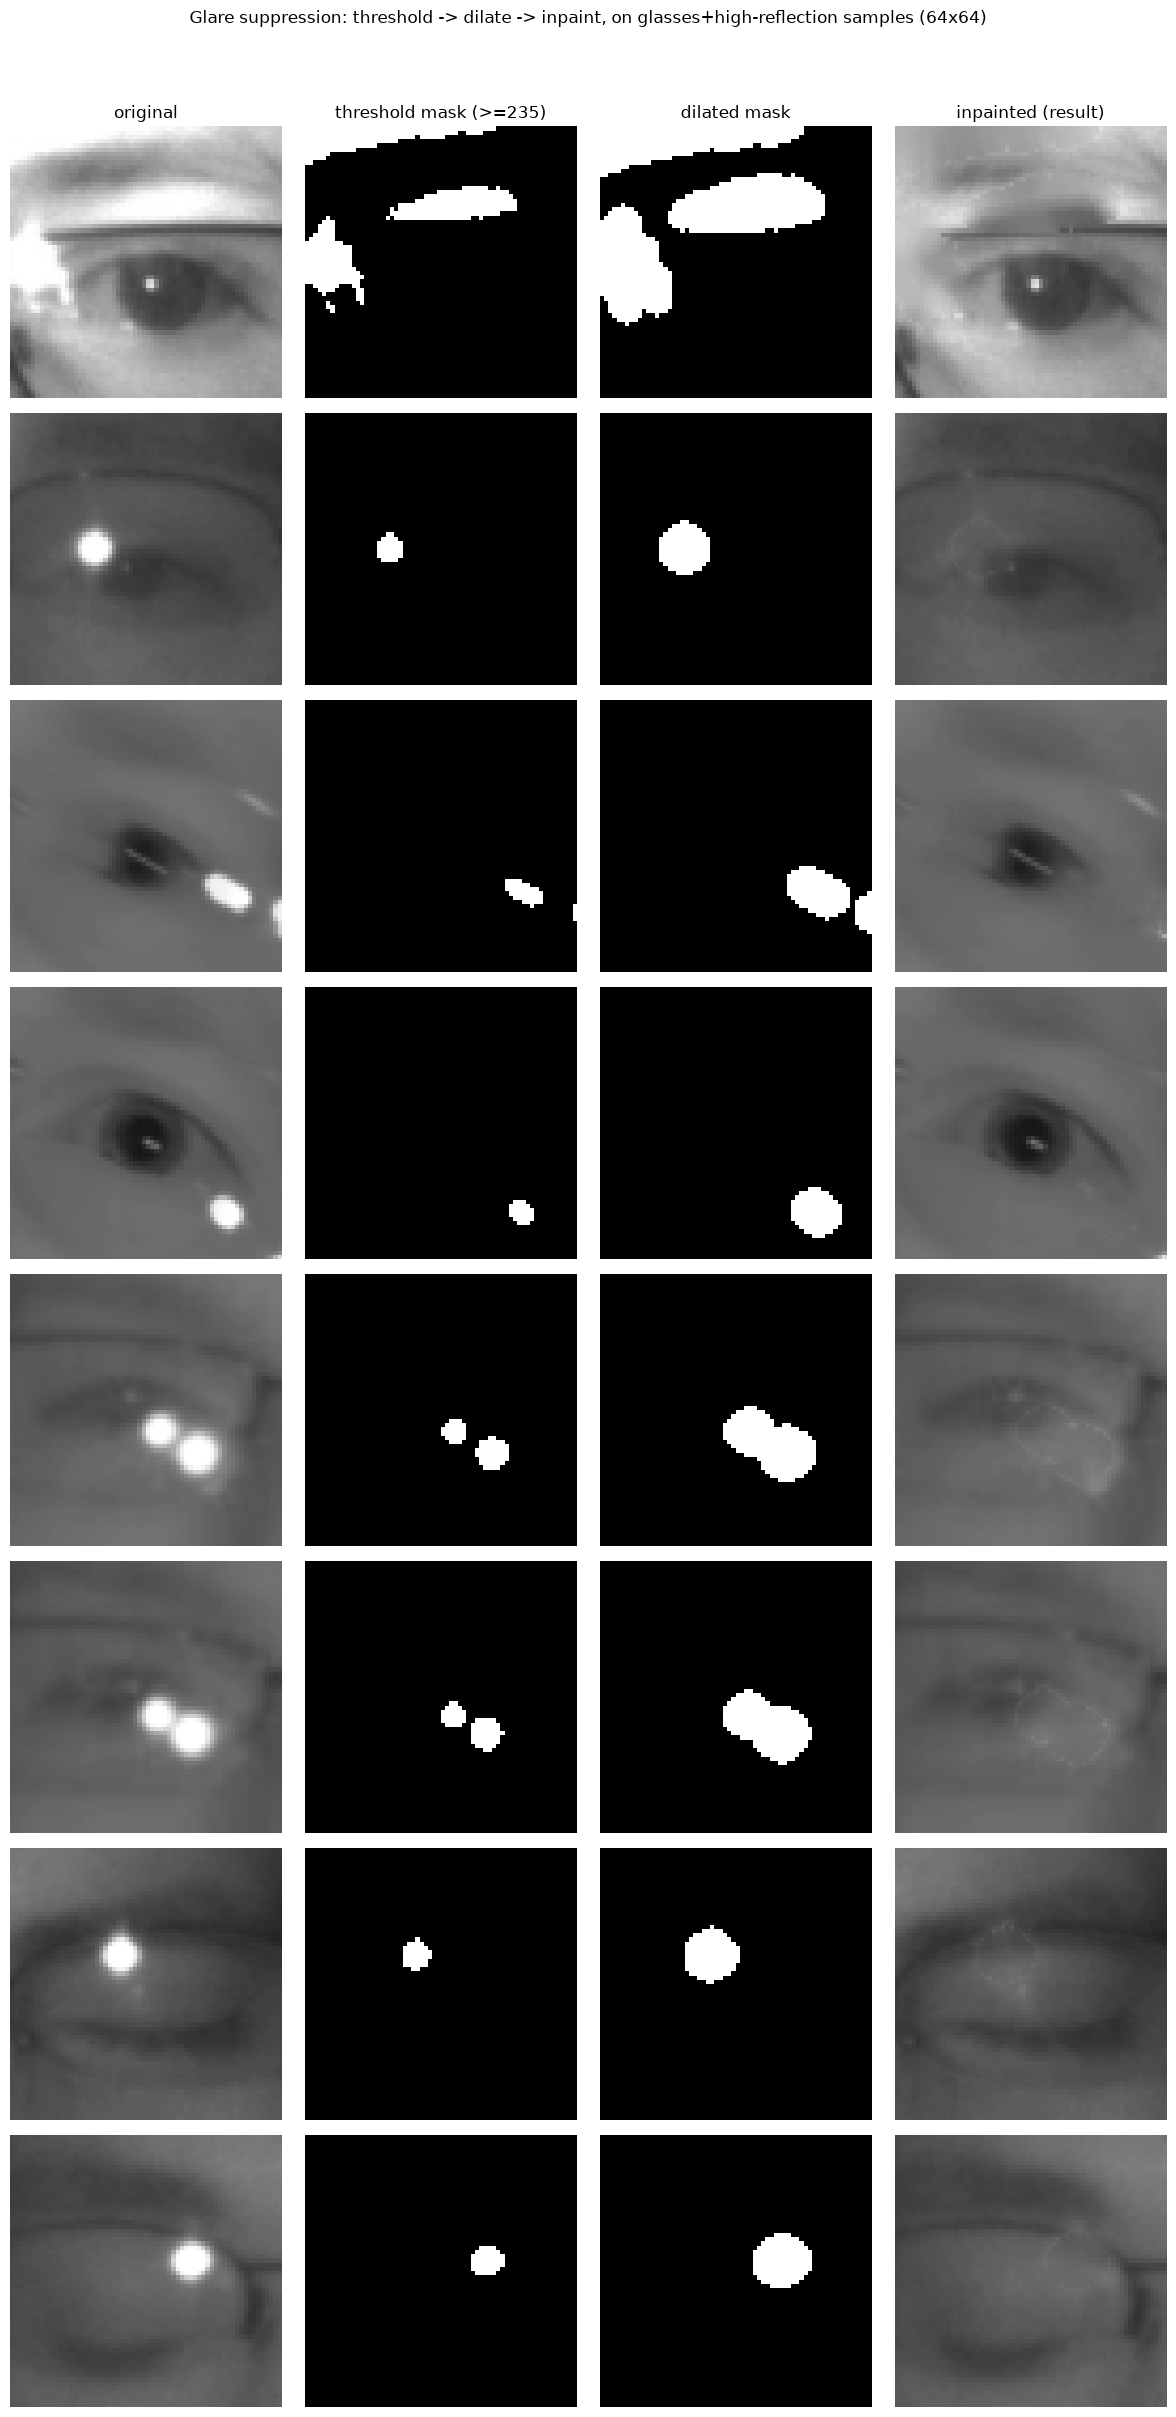

In [10]:
glasses_hi_refl = [s for s in samples if s.glasses == 1 and s.reflections == 2]
print(f"{len(glasses_hi_refl)} glasses+high-reflection samples in curated set")

fig, axes = plt.subplots(len(glasses_hi_refl), 4, figsize=(12, 3 * len(glasses_hi_refl)))
for row, s in enumerate(glasses_hi_refl):
    img = normalize_size(read_gray(s), 64, "resize")
    mask = (img >= 235).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask_dilated = cv2.dilate(mask, kernel)
    result = suppress_glare(img)

    axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title("original" if row == 0 else "")
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("threshold mask (>=235)" if row == 0 else "")
    axes[row, 2].imshow(mask_dilated, cmap="gray")
    axes[row, 2].set_title("dilated mask" if row == 0 else "")
    axes[row, 3].imshow(result, cmap="gray", vmin=0, vmax=255)
    axes[row, 3].set_title("inpainted (result)" if row == 0 else "")
    for ax in axes[row]:
        ax.axis("off")
    axes[row, 0].set_ylabel(s.path.stem, rotation=0, labelpad=40, fontsize=8)

fig.suptitle("Glare suppression: threshold -> dilate -> inpaint, on glasses+high-reflection samples (64x64)", y=1.005)
plt.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(RESULTS_DIR / "week2_glare_suppression.png", dpi=120)
plt.show()


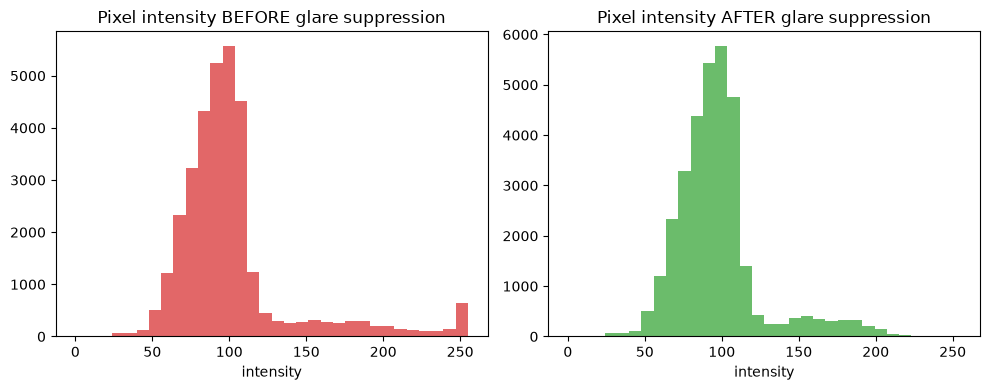

s0032_02096_0_1_1_2_1_02: mean 163.7->148.0, max 255->227
s0001_03185_0_1_1_2_0_01: mean 81.4->79.0, max 255->109
s0035_00133_0_1_1_2_1_02: mean 103.1->100.5, max 255->170
s0035_00185_0_1_1_2_1_02: mean 98.4->96.7, max 255->217
s0027_00471_0_1_1_2_1_01: mean 99.7->95.0, max 255->131
s0027_00439_0_1_1_2_1_01: mean 97.2->92.3, max 255->130
s0012_02650_0_1_0_2_0_01: mean 80.3->77.7, max 255->127
s0001_01056_0_1_0_2_0_01: mean 89.6->86.9, max 255->128


In [11]:
before_after_means = []
for s in glasses_hi_refl:
    img = normalize_size(read_gray(s), 64, "resize")
    result = suppress_glare(img)
    before_after_means.append((img.mean(), img.max(), result.mean(), result.max()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
before_flat = np.concatenate([normalize_size(read_gray(s), 64, "resize").ravel() for s in glasses_hi_refl])
after_flat = np.concatenate([suppress_glare(normalize_size(read_gray(s), 64, "resize")).ravel() for s in glasses_hi_refl])
axes[0].hist(before_flat, bins=32, range=(0, 255), color="tab:red", alpha=0.7)
axes[0].set_title("Pixel intensity BEFORE glare suppression")
axes[1].hist(after_flat, bins=32, range=(0, 255), color="tab:green", alpha=0.7)
axes[1].set_title("Pixel intensity AFTER glare suppression")
for ax in axes:
    ax.set_xlabel("intensity")
plt.tight_layout()
plt.show()

for (mb, xb, ma, xa), s in zip(before_after_means, glasses_hi_refl):
    print(f"{s.path.stem}: mean {mb:.1f}->{ma:.1f}, max {xb:.0f}->{xa:.0f}")


The saturated highlight pixels (255, forming the tail visible in the
"before" histogram) are removed after inpainting -- max intensity drops from
255 to a plausible in-range value for every sample, while mean intensity
barely moves (the hotspot is a small fraction of total pixels), confirming
the method removes the glare artifact without altering overall image
brightness. Behavior at 64x64 matches what was observed at 128x128 --
`suppress_glare`'s default parameters (threshold=235, dilate_px=3,
inpaint_radius=5) transfer without adjustment.


## 6. Hardest cases: bad lighting + high reflection, full pipeline

The 3 curated images that are simultaneously `lighting=0` (bad light) AND
`reflections=2` (high reflection) are the worst case this pipeline must
handle. Comparing raw input vs. the full `preprocess_pipeline` output at
the chosen 64x64 canonical size.


3 hardest-case samples (lighting=0 & reflections=2)


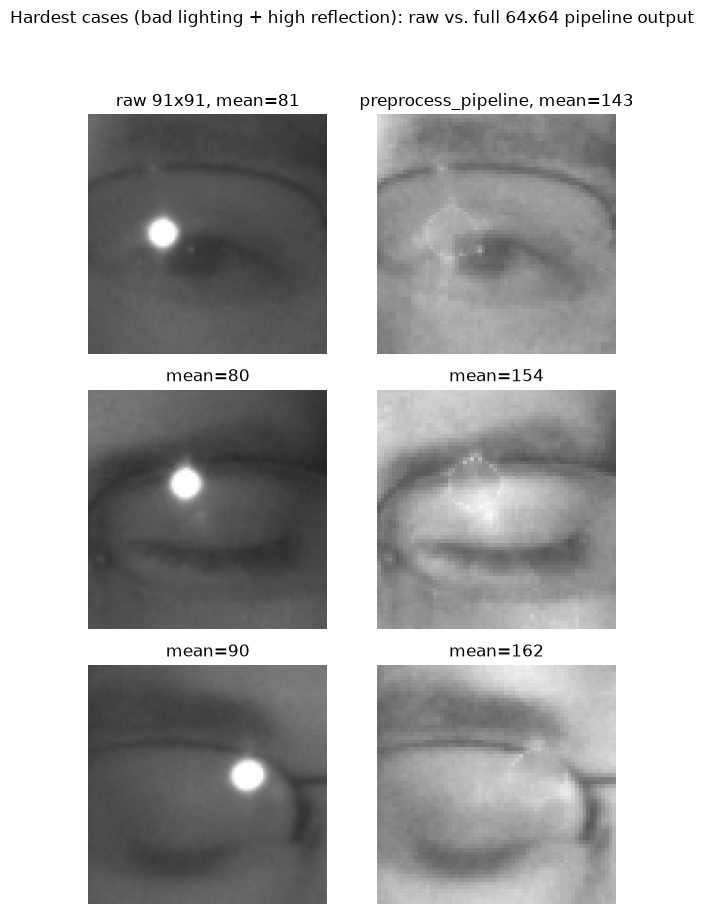

In [12]:
hardest = [s for s in samples if s.lighting == 0 and s.reflections == 2]
print(f"{len(hardest)} hardest-case samples (lighting=0 & reflections=2)")

cfg = PreprocessConfig()  # chosen defaults: target=64, resize, gamma=1.5, clip=2.0, tile_grid=(4,4)
fig, axes = plt.subplots(len(hardest), 2, figsize=(6, 3 * len(hardest)))
for row, s in enumerate(hardest):
    raw = read_gray(s)
    enhanced = preprocess_pipeline(raw, cfg)
    axes[row, 0].imshow(raw, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"raw {raw.shape[0]}x{raw.shape[1]}, mean={raw.mean():.0f}" if row == 0 else f"mean={raw.mean():.0f}")
    axes[row, 1].imshow(enhanced, cmap="gray", vmin=0, vmax=255)
    axes[row, 1].set_title(f"preprocess_pipeline, mean={enhanced.mean():.0f}" if row == 0 else f"mean={enhanced.mean():.0f}")
    for ax in axes[row]:
        ax.axis("off")

fig.suptitle("Hardest cases (bad lighting + high reflection): raw vs. full 64x64 pipeline output", y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(RESULTS_DIR / "week2_hardest_cases.png", dpi=120)
plt.show()


## Conclusion

Based on the measurements above:

- **Canonical size: 64x64.** Full-dataset stats (n=84,898) show every MRL
  crop is a perfect square (aspect ratio == 1.0 always) ranging 52-299 px,
  median 87 px, mean 93.4 px. A target of 64 **shrinks 94.3%** of images
  (`INTER_AREA`, information-reducing) and only **enlarges 4.4%**
  (`INTER_CUBIC`, information-inventing). A target of 128 would flip this
  the wrong way -- 89.9% of images would need to be *enlarged*, which means
  weeks 3-5's Otsu thresholding, morphological opening/closing, and Hough
  circle fitting would be run largely on interpolation artifacts rather
  than captured detail. 64 is also a fast, standard working size for the
  classical-feature + SVM/RF classifier planned for Week 6 (HOG/LBP
  extraction and inference stay cheap on CPU).
- **Resize mode: plain `resize` (not letterbox).** Since aspect ratio is
  exactly 1.0 for every image in the dataset, `resize` and `letterbox`
  are mathematically identical here (verified in Section 2) -- `resize` is
  chosen for simplicity and to avoid the black-border edge case
  entirely. `normalize_size` still implements `letterbox` for reuse on
  non-square inputs (e.g. Week-7 webcam eye ROIs before their own crop step).
- **CLAHE clip_limit: 2.0, tile_grid: (4,4).** Confirmed unchanged from the
  original decision, but only once tile_grid is corrected: the `(8,8)`
  grid carried over from target=128 gives 8x8px tiles at 64x64, which is
  too small for CLAHE's clip mechanism to respond to at all (Section 3 --
  std stays flat across the whole clip sweep). Switching to `(4,4)`
  restores 16x16px tiles (matching the original tile pixel size) and a
  clean, monotonic clip-limit response; clip=2.0 gives a strong contrast
  gain (std 16.5 -> 27.2, +65%) without the graininess visible past clip=4.
- **Gamma: 1.5.** Confirmed unchanged -- gamma is a pointwise LUT
  operation, independent of resolution, so the target=128 sweep numbers
  reproduce exactly at 64x64. Baseline mean intensity on the bad-lighting
  subset is 77.8 (dark); gamma=1.5 lifts it to ~114 (near mid-range) while
  saturated-pixel fraction stays flat (~0.13%, no clipping).
- **Glare suppression:** threshold (>=235) + morphological dilation (7x7
  ellipse) + Telea inpainting removes eyeglass IR hotspots (Section 5) --
  max intensity drops from 255 to a plausible value on every
  glasses+high-reflection sample, while mean intensity is preserved. Default
  parameters transfer from 128x128 to 64x64 without adjustment.

**This locks in `src/preprocess.py`'s `PreprocessConfig` defaults
(`target_size=64, resize_mode="resize", gamma=1.5, clahe_clip_limit=2.0,
clahe_tile_grid=(4,4)`) as the canonical Week-2 pipeline that Weeks 3-8
(segmentation, morphology, transforms, classification, live inference) all
call via `preprocess_pipeline`.**
